# Half-Truth Benchmark: Comprehensive Figures

Publication-ready figures for the Half-Truth benchmark results using:
- **tueplots** for ICML/NeurIPS styling
- **Paul Tol's colorblind-friendly palette** for accessibility
- **Micro-averaged metrics** for fair comparison

## Sections:
1. **Overall Results & Rankings** - Bar charts of HT-Accuracy across all models
2. **Entity vs Relation Breakdown** - Category-wise performance comparison
3. **Per-Condition Heatmaps** - Detailed condition-level analysis
4. **Full-Truth Analysis** - FT > HT accuracy (score_long_correct based)
5. **Consistency Analysis** - FT > ST (adding correct info helps)

In [1]:
# =============================================================================
# SETUP: Imports, Style Configuration, Data Loading
# =============================================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import seaborn as sns
import os

# Tueplots for publication-ready figures
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# =============================================================================
# STYLE CONFIGURATION
# =============================================================================

# Paul Tol's colorblind-friendly bright palette
COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

# Semantic color assignments (consistent across all figures)
COLOR_CORRECT = COLORBLIND_PALETTE[2]    # Green - correct/anchor
COLOR_WRONG = COLORBLIND_PALETTE[1]      # Red/Pink - wrong/half-truth
COLOR_BASELINE = COLORBLIND_PALETTE[-1]  # Grey - baseline (CLIP)
COLOR_OURS = COLORBLIND_PALETTE[2]       # Green - our method (CS-CLIP)
COLOR_ENTITY = COLORBLIND_PALETTE[0]     # Blue - Entity category
COLOR_RELATION = COLORBLIND_PALETTE[4]   # Orange - Relation category

# Model styling
MODEL_COLORS = {
    'CLIP': COLORBLIND_PALETTE[-1],       # Grey (baseline)
    'NegCLIP': COLORBLIND_PALETTE[1],     # Red
    # 'CS-CLIP': COLORBLIND_PALETTE[2],     # Green (ours)
    'SigLIP': COLORBLIND_PALETTE[0],      # Blue
    'SigLIP2': COLORBLIND_PALETTE[4],     # Orange
    # 'CyCLIP': COLORBLIND_PALETTE[3],      # Yellow
    # 'TripletCLIP': COLORBLIND_PALETTE[5], # Magenta
}

# Default tueplots style with seaborn enhancement
def apply_tueplots_style(half_width=False, context='paper'):
    """Apply tueplots ICML 2024 style with seaborn enhancements."""
    # Reset to defaults first
    plt.rcdefaults()
    
    # Apply tueplots
    if half_width:
        plt.rcParams.update(figsizes.icml2024_half())
    else:
        plt.rcParams.update(figsizes.icml2024_full())
    plt.rcParams.update(fontsizes.icml2024())
    
    # Core display settings
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['text.color'] = 'black'
    plt.rcParams['axes.labelcolor'] = 'black'
    plt.rcParams['xtick.color'] = 'black'
    plt.rcParams['ytick.color'] = 'black'
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Seaborn styling for cleaner plots
    sns.set_context(context, font_scale=0.9)
    sns.set_style("whitegrid", {
        'axes.edgecolor': '0.2',
        'grid.color': '0.9',
        'grid.linestyle': '-',
        'grid.linewidth': 0.4,
    })


def get_model_color(model_name):
    """Get color for a model (consistent across figures)."""
    if model_name == 'CLIP':
        return COLOR_BASELINE
    elif model_name == 'CS-CLIP':
        return COLOR_OURS
    else:
        return COLORBLIND_PALETTE[0]  # Default blue


apply_tueplots_style()
print("✓ Style configured: tueplots ICML 2024 + seaborn + Paul Tol colorblind palette")
print(f"  Palette: {COLORBLIND_PALETTE[:6]}")

✓ Style configured: tueplots ICML 2024 + seaborn + Paul Tol colorblind palette
  Palette: ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']


In [3]:
# =============================================================================
# DATA LOADING & MODEL DISCOVERY
# =============================================================================

RESULTS_BASE_DIR = Path("../../results_new")

# Auto-discover all half_truth models
def discover_models(base_dir):
    """Auto-discover all half_truth model folders."""
    models = {}
    base_path = Path(base_dir)
    
    # Model name mapping: folder suffix -> display name
    NAME_MAP = {
        "00_baseline_openai_vitb32": "CLIP",
        "laclip_cc12m_vitb32": "LA-CLIP",
        "negclip_coco_vitb32": "NegCLIP",
        "tripletclip_cc12m_vitb12": "TripletCLIP",
        "cyclip_vitb32": "CyCLIP",
        "ce_clip_vitb32": "CE-CLIP",
        "con_clip_vitb32": "CON-CLIP",
        "dac_vitb32_llm": "DAC-LLM",
        "dac_vitb32_sam": "DAC-SAM",
        "degla_vitb32": "DEGLA",
        "clic_cogvlm_vitb32_laion": "CLIC-LAION",
        "clic_cogvlm_vitb32_pixpr_redcaps": "CLIC-RedCaps",
        "clove_vitb32_laioncoco": "CLoVe",
        "fsc_clip_cc3m_vitb32": "FSC-CLIP-CC3M",
        "fsc_clip_coco_vitb32": "FSC-CLIP-COCO",
        "fsc_clip_laioncoco_vitb32": "FSC-CLIP-LAION",
        "labclip_vitb32": "LabCLIP",
        "readclip_vitb32": "ReadCLIP",
        "siglip_vitb16": "SigLIP",
        "siglip2_vitb16": "SigLIP2",
        "tsvlc_vitb32": "TSVLC",
        "cs_clip_negclip_vitb32": "CS-CLIP",
    }
    
    # Model metadata
    IS_BASELINE = {'CLIP'}
    IS_OURS = {'CS-CLIP'}
    
    for folder in sorted(base_path.iterdir()):
        if folder.is_dir() and folder.name.startswith("half_truth_coco_"):
            suffix = folder.name.replace("half_truth_coco_", "")
            display_name = NAME_MAP.get(suffix, suffix)
            models[display_name] = {
                'folder': folder.name,
                'is_baseline': display_name in IS_BASELINE,
                'is_ours': display_name in IS_OURS,
            }
    
    return models


def load_model_results(base_dir, model_folder):
    """Load results for a single model."""
    model_path = Path(base_dir) / model_folder
    results_file = model_path / 'results.json'
    
    if results_file.exists():
        with open(results_file, 'r') as f:
            data = json.load(f)
            if 'results' in data:
                return pd.DataFrame(data['results'])
            else:
                return pd.DataFrame(data)
    return None


def load_all_models(base_dir, models):
    """Load results for all models."""
    all_results = {}
    
    for display_name, meta in models.items():
        try:
            df = load_model_results(base_dir, meta['folder'])
            if df is not None:
                df['model'] = display_name
                df['is_baseline'] = meta['is_baseline']
                df['is_ours'] = meta['is_ours']
                all_results[display_name] = df
                print(f"  ✓ {display_name}: {len(df)} samples")
            else:
                print(f"  ⚠ {display_name}: No results found")
        except Exception as e:
            print(f"  ✗ {display_name}: Error - {e}")
    
    return all_results


# Discover and load models
print("="*70)
print("DISCOVERING AND LOADING HALF-TRUTH RESULTS")
print("="*70)

MODELS = discover_models(RESULTS_BASE_DIR)
FILTER = [
    "CLIP",
    # "NegCLIP",
    "SigLIP",
    # "SigLIP2",
]
MODELS = {name: folder for name, folder in MODELS.items() if name in
    FILTER}

print(f"Discovered {len(MODELS)} models\n")

all_model_results = load_all_models(RESULTS_BASE_DIR, MODELS)
print(f"\n✓ Loaded {len(all_model_results)} models total")

DISCOVERING AND LOADING HALF-TRUTH RESULTS
Discovered 2 models

  ✓ CLIP: 34675 samples
  ✓ SigLIP: 34675 samples

✓ Loaded 2 models total


In [4]:
# =============================================================================
# CONDITION & METRIC DEFINITIONS
# =============================================================================

# Condition mapping: internal name -> (display_name, category)
# Excluding relation_negation
CONDITION_MAP = {
    # Entity foils (adding wrong component)
    'component_easy': ('+Obj', 'Entity'),
    'component_hard': ('+Attr', 'Entity'),
    'component_random': ('+Rand', 'Entity'),
    # Relation foils (modifying relation)
    'attribute_wrong': ('Attr', 'Relation'),
    'object_wrong': ('Obj', 'Relation'),
    'relation_antonym': ('Ant', 'Relation'),
    'relation_swap': ('Swap', 'Relation'),
    'subject_wrong': ('Subj', 'Relation'),
}

ENTITY_CONDITIONS = ['component_easy', 'component_hard', 'component_random']
RELATION_CONDITIONS = ['attribute_wrong', 'object_wrong', 'relation_antonym', 
                       'relation_swap', 'subject_wrong']
ALL_CONDITIONS = ENTITY_CONDITIONS + RELATION_CONDITIONS

# =============================================================================
# METRIC COMPUTATION UTILITIES
# =============================================================================

def filter_negation(df):
    """Filter out relation_negation condition."""
    return df[df['condition'] != 'relation_negation'].copy()


def compute_ht_accuracy(df, conditions=None, with_ci=False, n_bootstrap=200):
    """
    Compute HT-Accuracy: proportion where model prefers anchor over half-truth.
    HT-Acc = ST wins only if score_short_correct > score_long_incorrect (strict)
    Ties go to half-truth.
    
    Args:
        df: DataFrame with score columns
        conditions: List of conditions to filter (None = all)
        with_ci: Whether to compute bootstrap 95% CI
        n_bootstrap: Number of bootstrap samples (200 is sufficient for visualization)
    
    Returns:
        accuracy (%), optionally (acc, ci_low, ci_high)
    """
    df_filtered = filter_negation(df)
    
    if conditions:
        df_filtered = df_filtered[df_filtered['condition'].isin(conditions)]
    
    if len(df_filtered) == 0:
        return (np.nan, np.nan, np.nan) if with_ci else np.nan
    
    # Re-compute from raw scores: ST wins only if strictly greater (ties go to HT)
    st_wins = (df_filtered['score_short_correct'] > df_filtered['score_long_incorrect']).astype(float)
    acc = st_wins.mean() * 100
    
    if with_ci:
        n = len(df_filtered)
        # Vectorized bootstrap for speed
        rng = np.random.default_rng(42)
        idx = rng.integers(0, n, size=(n_bootstrap, n))
        vals = st_wins.values
        bootstrap = vals[idx].mean(axis=1) * 100
        ci_low = np.percentile(bootstrap, 2.5)
        ci_high = np.percentile(bootstrap, 97.5)
        return acc, ci_low, ci_high
    
    return acc


def compute_ft_accuracy(df, conditions=None, with_ci=False, n_bootstrap=200):
    """
    Compute FT-Accuracy: proportion where Full-Truth > Half-Truth.
    Uses score_long_correct > score_long_incorrect
    
    This tests if the model correctly prefers the full correct caption
    over its minimally edited (half-truth) counterpart.
    """
    df_filtered = filter_negation(df)
    
    if conditions:
        df_filtered = df_filtered[df_filtered['condition'].isin(conditions)]
    
    if len(df_filtered) == 0 or 'score_long_correct' not in df_filtered.columns:
        return (np.nan, np.nan, np.nan) if with_ci else np.nan
    
    ft_wins = (df_filtered['score_long_correct'] > df_filtered['score_long_incorrect']).astype(float)
    acc = ft_wins.mean() * 100
    
    if with_ci:
        n = len(df_filtered)
        rng = np.random.default_rng(42)
        idx = rng.integers(0, n, size=(n_bootstrap, n))
        vals = ft_wins.values
        bootstrap = vals[idx].mean(axis=1) * 100
        ci_low = np.percentile(bootstrap, 2.5)
        ci_high = np.percentile(bootstrap, 97.5)
        return acc, ci_low, ci_high
    
    return acc


def compute_consistency(df, conditions=None, with_ci=False, n_bootstrap=200):
    """
    Compute Consistency: proportion where Full-Truth > Short-Truth.
    Uses score_long_correct > score_short_correct
    
    This tests if adding more correct information increases the score.
    """
    df_filtered = filter_negation(df)
    
    if conditions:
        df_filtered = df_filtered[df_filtered['condition'].isin(conditions)]
    
    if len(df_filtered) == 0 or 'score_long_correct' not in df_filtered.columns:
        return (np.nan, np.nan, np.nan) if with_ci else np.nan
    
    consistent = (df_filtered['score_long_correct'] > df_filtered['score_short_correct']).astype(float)
    acc = consistent.mean() * 100
    
    if with_ci:
        n = len(df_filtered)
        rng = np.random.default_rng(42)
        idx = rng.integers(0, n, size=(n_bootstrap, n))
        vals = consistent.values
        bootstrap = vals[idx].mean(axis=1) * 100
        ci_low = np.percentile(bootstrap, 2.5)
        ci_high = np.percentile(bootstrap, 97.5)
        return acc, ci_low, ci_high
    
    return acc


print("✓ Metric computation utilities defined")
print("  - HT-Accuracy: score_short_correct > score_long_incorrect (ties go to HT)")
print("  - FT-Accuracy: score_long_correct > score_long_incorrect")
print("  - Consistency: score_long_correct > score_short_correct")

✓ Metric computation utilities defined
  - HT-Accuracy: score_short_correct > score_long_incorrect (ties go to HT)
  - FT-Accuracy: score_long_correct > score_long_incorrect
  - Consistency: score_long_correct > score_short_correct


In [5]:
# =============================================================================
# BUILD SUMMARY DATAFRAMES FOR ALL MODELS
# =============================================================================

def build_summary_df(all_results, metric_fn, conditions_dict=None):
    """
    Build summary DataFrame for all models with a given metric function.
    
    Args:
        all_results: Dict of model_name -> DataFrame
        metric_fn: Function(df, conditions, with_ci) -> accuracy or (acc, ci_low, ci_high)
        conditions_dict: Dict of category_name -> conditions list
                         If None, uses {'Overall': ALL_CONDITIONS, 'Entity': ENTITY, 'Relation': RELATION}
    
    Returns:
        DataFrame with columns: Model, <category_acc>, <category_ci_low>, <category_ci_high>, ...
    """
    if conditions_dict is None:
        conditions_dict = {
            'Overall': ALL_CONDITIONS,
            'Entity': ENTITY_CONDITIONS,
            'Relation': RELATION_CONDITIONS,
        }
    
    records = []
    for model_name, df in all_results.items():
        record = {'Model': model_name}
        
        for cat_name, conditions in conditions_dict.items():
            acc, ci_low, ci_high = metric_fn(df, conditions, with_ci=True)
            record[cat_name] = acc
            record[f'{cat_name}_ci_low'] = ci_low
            record[f'{cat_name}_ci_high'] = ci_high
        
        # Compute gap (Entity - Relation) if both exist
        if 'Entity' in conditions_dict and 'Relation' in conditions_dict:
            if not np.isnan(record.get('Entity', np.nan)) and not np.isnan(record.get('Relation', np.nan)):
                record['Gap'] = record['Entity'] - record['Relation']
        
        records.append(record)
    
    return pd.DataFrame(records).set_index('Model')


# Build summary DataFrames
print("="*70)
print("BUILDING SUMMARY DATAFRAMES")
print("="*70)

# HT-Accuracy (main metric)
ht_summary_df = build_summary_df(all_model_results, compute_ht_accuracy)
print(f"\n✓ HT-Accuracy Summary ({len(ht_summary_df)} models)")

# FT-Accuracy (Full-Truth > Half-Truth)
ft_summary_df = build_summary_df(all_model_results, compute_ft_accuracy)
print(f"✓ FT-Accuracy Summary ({len(ft_summary_df)} models)")

# Consistency (Full-Truth > Short-Truth)
cons_summary_df = build_summary_df(all_model_results, compute_consistency)
print(f"✓ Consistency Summary ({len(cons_summary_df)} models)")

# Sort by Overall accuracy
ht_summary_df = ht_summary_df.sort_values('Overall', ascending=False)
ft_summary_df = ft_summary_df.sort_values('Overall', ascending=False)
cons_summary_df = cons_summary_df.sort_values('Overall', ascending=False)

# Display HT-Accuracy summary
print("\n" + "="*70)
print("HT-ACCURACY SUMMARY (Higher = Better)")
print("="*70)
display_cols = ['Overall', 'Entity', 'Relation', 'Gap']
print(ht_summary_df[display_cols].round(1).to_string())

BUILDING SUMMARY DATAFRAMES

✓ HT-Accuracy Summary (2 models)
✓ FT-Accuracy Summary (2 models)
✓ Consistency Summary (2 models)

HT-ACCURACY SUMMARY (Higher = Better)
        Overall  Entity  Relation   Gap
Model                                  
SigLIP     45.7    56.9      38.8  18.1
CLIP       40.6    52.9      32.9  20.0


## Section 1: Overall HT-Accuracy Rankings

Horizontal bar chart showing all models ranked by their overall HT-Accuracy.
- **HT-Accuracy** = proportion where model correctly prefers anchor over half-truth
- Higher is better (inverted from "vulnerability")

/tmp/ipykernel_2999912/1688045198.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2999912/1688045198.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


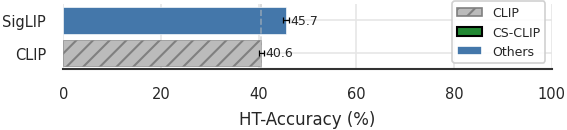

✓ Saved: ../paper_figures/ht_overall_ranking.pdf


In [6]:
# =============================================================================
# FIGURE 1: Overall HT-Accuracy Rankings (Horizontal Bar Chart)
# =============================================================================

apply_tueplots_style(half_width=False)

# Sort by Overall accuracy
df_plot = ht_summary_df.sort_values('Overall', ascending=True).copy()
models = df_plot.index.tolist()
accuracies = df_plot['Overall'].values
ci_low = df_plot['Overall_ci_low'].values
ci_high = df_plot['Overall_ci_high'].values

# Compute error bars
yerr_low = accuracies - ci_low
yerr_high = ci_high - accuracies

colors = [get_model_color(m) for m in models]

# Create figure - compact size
fig, ax = plt.subplots(figsize=(4.2, 0.28 * len(models)))

y_pos = np.arange(len(models))
bars = ax.barh(y_pos, accuracies, xerr=[yerr_low, yerr_high], 
               color=colors, edgecolor='white', linewidth=0.3,
               capsize=1.5, error_kw={'linewidth': 0.6, 'capthick': 0.6})

# Highlight baseline and ours
for i, (bar, model) in enumerate(zip(bars, models)):
    if model == 'CLIP':
        bar.set_hatch('///')
        bar.set_edgecolor('gray')
    elif model == 'CS-CLIP':
        bar.set_edgecolor('black')
        bar.set_linewidth(1.2)

# Add value labels
for i, (acc, model) in enumerate(zip(accuracies, models)):
    ax.text(acc + 0.8, i, f'{acc:.1f}', va='center', ha='left', fontsize=6)

# Reference line at CLIP baseline
clip_acc = ht_summary_df.loc['CLIP', 'Overall']
ax.axvline(x=clip_acc, color=COLOR_BASELINE, linestyle='--', linewidth=0.8, alpha=0.6)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(models, fontsize=7)
ax.set_xlabel('HT-Accuracy (%)', fontsize=8)
ax.set_xlim(0, 100)
ax.tick_params(axis='x', labelsize=7)

# Compact legend
legend_elements = [
    Patch(facecolor=COLOR_BASELINE, edgecolor='gray', hatch='///', label='CLIP'),
    Patch(facecolor=COLOR_OURS, edgecolor='black', linewidth=1, label='CS-CLIP'),
    Patch(facecolor=COLORBLIND_PALETTE[0], edgecolor='white', label='Others'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=6, frameon=True, framealpha=0.9)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig('../paper_figures/ht_overall_ranking.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_overall_ranking.pdf")

## Section 2: Entity vs Relation Breakdown

Grouped bar chart comparing Entity and Relation accuracy for each model.
- **Entity**: Adding wrong objects/attributes
- **Relation**: Modifying subject-object relationships

/tmp/ipykernel_2999912/2550601719.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


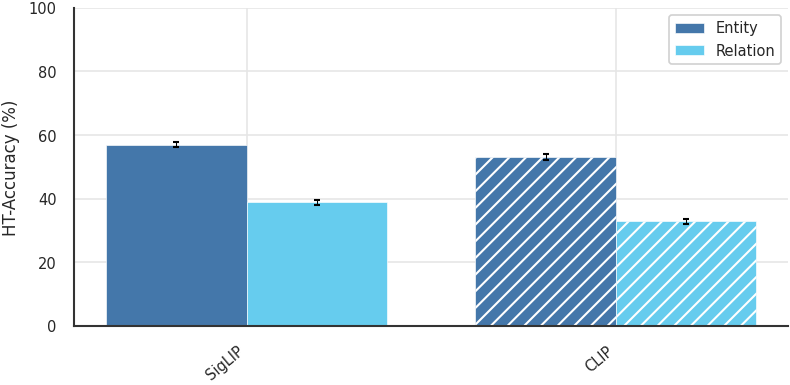

✓ Saved: ../paper_figures/ht_entity_vs_relation.pdf


In [7]:
# =============================================================================
# FIGURE 2: Entity vs Relation Grouped Bar Chart
# =============================================================================

apply_tueplots_style(half_width=False)

# Select top N models for readability (sorted by overall)
TOP_N = 10
df_plot = ht_summary_df.head(TOP_N).copy()
models = df_plot.index.tolist()

# Data
entity_acc = df_plot['Entity'].values
relation_acc = df_plot['Relation'].values
entity_ci_low = entity_acc - df_plot['Entity_ci_low'].values
entity_ci_high = df_plot['Entity_ci_high'].values - entity_acc
relation_ci_low = relation_acc - df_plot['Relation_ci_low'].values
relation_ci_high = df_plot['Relation_ci_high'].values - relation_acc

# Create figure - compact
fig, ax = plt.subplots(figsize=(5.5, 2.8))

x = np.arange(len(models))
width = 0.38

# Bars with seaborn-like styling
bars_entity = ax.bar(x - width/2, entity_acc, width, 
                     yerr=[entity_ci_low, entity_ci_high],
                     label='Entity', color=COLOR_ENTITY, edgecolor='white', 
                     linewidth=0.3, capsize=1.5, error_kw={'linewidth': 0.5})

bars_relation = ax.bar(x + width/2, relation_acc, width,
                       yerr=[relation_ci_low, relation_ci_high],
                       label='Relation', color=COLOR_RELATION, edgecolor='white',
                       linewidth=0.3, capsize=1.5, error_kw={'linewidth': 0.5})

# Highlight CS-CLIP and CLIP
for i, model in enumerate(models):
    if model == 'CS-CLIP':
        bars_entity[i].set_edgecolor('black')
        bars_entity[i].set_linewidth(1.5)
        bars_relation[i].set_edgecolor('black')
        bars_relation[i].set_linewidth(1.5)
    elif model == 'CLIP':
        bars_entity[i].set_hatch('///')
        bars_relation[i].set_hatch('///')

# Formatting - no title
ax.set_ylabel('HT-Accuracy (%)', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=40, ha='right', fontsize=7)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=7)
ax.legend(loc='upper right', fontsize=7, frameon=True, framealpha=0.9)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig('../paper_figures/ht_entity_vs_relation.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_entity_vs_relation.pdf")

## Section 3: Per-Condition Heatmap

Heatmap showing HT-Accuracy for each model × condition combination.
Conditions grouped by Entity (left) and Relation (right).

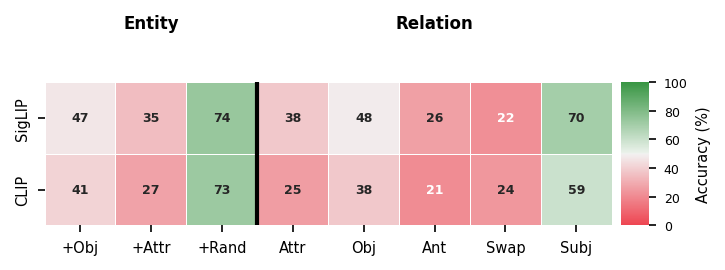

✓ Saved: ../paper_figures/ht_per_condition_heatmap.pdf


In [8]:
# =============================================================================
# FIGURE 3: Per-Condition Heatmap (Seaborn)
# =============================================================================

# Reset style for heatmap (avoid layout conflicts)
plt.rcdefaults()
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Build per-condition accuracy matrix
def build_per_condition_matrix(all_results, condition_map):
    """Build model x condition accuracy matrix."""
    records = []
    
    for model_name, df in all_results.items():
        df_filtered = filter_negation(df)
        
        for condition, (display_name, category) in condition_map.items():
            subset = df_filtered[df_filtered['condition'] == condition]
            if len(subset) == 0:
                continue
            
            # Re-compute from raw scores: ST wins only if strictly greater (ties go to HT)
            st_wins = (subset['score_short_correct'] > subset['score_long_incorrect']).astype(float)
            acc = st_wins.mean() * 100
            records.append({
                'model': model_name,
                'condition': condition,
                'display_name': display_name,
                'category': category,
                'accuracy': acc,
            })
    
    df_records = pd.DataFrame(records)
    pivot = df_records.pivot(index='model', columns='condition', values='accuracy')
    return pivot, df_records


# Build matrix
per_cond_matrix, per_cond_df = build_per_condition_matrix(all_model_results, CONDITION_MAP)

# Order: Entity conditions first, then Relation
ordered_conditions = ENTITY_CONDITIONS + RELATION_CONDITIONS
ordered_conditions = [c for c in ordered_conditions if c in per_cond_matrix.columns]
per_cond_matrix = per_cond_matrix[ordered_conditions]

# Sort models by overall accuracy
model_order = ht_summary_df.index.tolist()
per_cond_matrix = per_cond_matrix.reindex(model_order)

# Create display names for conditions
display_names = [CONDITION_MAP[c][0] for c in ordered_conditions]

# Create figure using gridspec for better colorbar control
fig = plt.figure(figsize=(5.2, 0.32 * len(model_order) + 0.6))
gs = fig.add_gridspec(1, 2, width_ratios=[20, 1], wspace=0.03)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

# Seaborn heatmap with better colormap (red=low, green=high for accuracy)
cmap = sns.diverging_palette(10, 130, s=80, l=55, as_cmap=True)

hm = sns.heatmap(per_cond_matrix, ax=ax, cmap=cmap, vmin=0, vmax=100,
                 annot=True, fmt='.0f', annot_kws={'size': 6, 'weight': 'bold'},
                 cbar_ax=cax, cbar_kws={'label': 'Accuracy (%)'},
                 linewidths=0.4, linecolor='white',
                 xticklabels=display_names, yticklabels=model_order)

# Category separator
n_entity = len([c for c in ENTITY_CONDITIONS if c in per_cond_matrix.columns])
ax.axvline(x=n_entity, color='black', linewidth=2)

# Category labels at top
ax.text(n_entity / 2, -0.7, 'Entity', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.text(n_entity + (len(ordered_conditions) - n_entity) / 2, -0.7, 'Relation', 
        ha='center', va='bottom', fontsize=8, fontweight='bold')

# Formatting - no title
ax.tick_params(axis='both', labelsize=7)
ax.set_xlabel('')
ax.set_ylabel('')

# Adjust colorbar
cax.tick_params(labelsize=6)
cax.set_ylabel('Accuracy (%)', fontsize=7)

# Save without tight_layout (using gridspec handles spacing)
plt.savefig('../paper_figures/ht_per_condition_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_per_condition_heatmap.pdf")

## Section 4: Combined HT & FT-Accuracy Figures

Side-by-side comparison of Half-Truth Accuracy (ST > HT) and Full-Truth Accuracy (FT > HT).

/tmp/ipykernel_2999912/366165746.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2999912/366165746.py:84: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


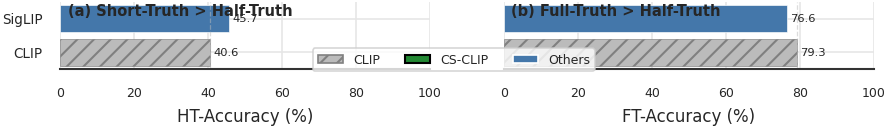

✓ Saved: ../paper_figures/ht_ft_combined_ranking.pdf


In [9]:
# =============================================================================
# FIGURE 4: Combined HT-Accuracy + FT-Accuracy Side-by-Side Rankings
# =============================================================================

apply_tueplots_style(half_width=False)

# Get data - sort by HT-Acc Overall
ht_sorted = ht_summary_df.sort_values('Overall', ascending=True).copy()
ft_sorted = ft_summary_df.reindex(ht_sorted.index)  # Same order as HT

models = ht_sorted.index.tolist()
ht_acc = ht_sorted['Overall'].values
ft_acc = ft_sorted['Overall'].values

# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 0.28 * len(models)), sharey=True)

y_pos = np.arange(len(models))

# Colors
colors = [get_model_color(m) for m in models]

# --- Left: HT-Accuracy ---
bars1 = ax1.barh(y_pos, ht_acc, color=colors, edgecolor='white', linewidth=0.3)
for i, (bar, model) in enumerate(zip(bars1, models)):
    if model == 'CLIP':
        bar.set_hatch('///')
        bar.set_edgecolor('gray')
    elif model == 'CS-CLIP':
        bar.set_edgecolor('black')
        bar.set_linewidth(1.2)

# Value labels
for i, acc in enumerate(ht_acc):
    ax1.text(acc + 0.8, i, f'{acc:.1f}', va='center', ha='left', fontsize=5.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(models, fontsize=6.5)
ax1.set_xlabel('HT-Accuracy (%)', fontsize=8)
ax1.set_xlim(0, 100)
ax1.tick_params(axis='x', labelsize=6)
ax1.text(0.02, 0.98, '(a) Short-Truth > Half-Truth', transform=ax1.transAxes, 
         fontsize=7, fontweight='bold', va='top')

# Reference line
clip_ht = ht_sorted.loc['CLIP', 'Overall']
ax1.axvline(x=clip_ht, color=COLOR_BASELINE, linestyle='--', linewidth=0.6, alpha=0.5)

# --- Right: FT-Accuracy ---
bars2 = ax2.barh(y_pos, ft_acc, color=colors, edgecolor='white', linewidth=0.3)
for i, (bar, model) in enumerate(zip(bars2, models)):
    if model == 'CLIP':
        bar.set_hatch('///')
        bar.set_edgecolor('gray')
    elif model == 'CS-CLIP':
        bar.set_edgecolor('black')
        bar.set_linewidth(1.2)

# Value labels
for i, acc in enumerate(ft_acc):
    if not np.isnan(acc):
        ax2.text(acc + 0.8, i, f'{acc:.1f}', va='center', ha='left', fontsize=5.5)

ax2.set_xlabel('FT-Accuracy (%)', fontsize=8)
ax2.set_xlim(0, 100)
ax2.tick_params(axis='x', labelsize=6)
ax2.text(0.02, 0.98, '(b) Full-Truth > Half-Truth', transform=ax2.transAxes, 
         fontsize=7, fontweight='bold', va='top')

# Reference line
clip_ft = ft_sorted.loc['CLIP', 'Overall']
ax2.axvline(x=clip_ft, color=COLOR_BASELINE, linestyle='--', linewidth=0.6, alpha=0.5)

# Shared legend at bottom
legend_elements = [
    Patch(facecolor=COLOR_BASELINE, edgecolor='gray', hatch='///', label='CLIP'),
    Patch(facecolor=COLOR_OURS, edgecolor='black', linewidth=1, label='CS-CLIP'),
    Patch(facecolor=COLORBLIND_PALETTE[0], edgecolor='white', label='Others'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=6, 
           frameon=True, bbox_to_anchor=(0.5, -0.02))

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('../paper_figures/ht_ft_combined_ranking.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_ft_combined_ranking.pdf")

## Section 7: Radar Chart (Multi-Metric Comparison)

Radar chart comparing key models across multiple conditions for at-a-glance comparison.

/tmp/ipykernel_2999912/1236558834.py:37: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, values, 'o-', linewidth=linewidth, linestyle=linestyle,
/tmp/ipykernel_2999912/1236558834.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


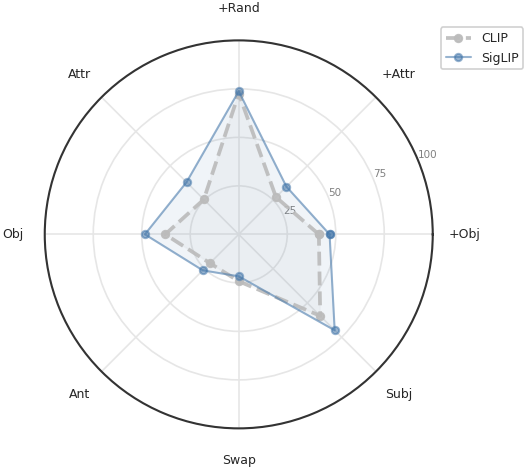

✓ Saved: ../paper_figures/ht_radar_chart.pdf


In [10]:
# =============================================================================
# FIGURE 7: Radar Chart for Key Models
# =============================================================================

from math import pi

apply_tueplots_style(half_width=True)

# Select key models for comparison
KEY_MODELS = ['CLIP', 'NegCLIP', 'SigLIP', 'SigLIP2', 'CS-CLIP']
KEY_MODELS = [m for m in KEY_MODELS if m in per_cond_matrix.index]

# Get per-condition data
radar_data = per_cond_matrix.loc[KEY_MODELS].copy()

# Categories (conditions)
categories = [CONDITION_MAP[c][0] for c in radar_data.columns]
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the loop

# Create figure (no title)
fig, ax = plt.subplots(figsize=(3.8, 3.8), subplot_kw=dict(polar=True))

# Plot each model
for i, model in enumerate(KEY_MODELS):
    values = radar_data.loc[model].values.tolist()
    values += values[:1]  # Complete the loop
    
    color = get_model_color(model)
    linewidth = 1.8 if model in ['CS-CLIP', 'CLIP'] else 1
    linestyle = '--' if model == 'CLIP' else '-'
    alpha = 0.9 if model in ['CS-CLIP', 'CLIP'] else 0.55
    
    ax.plot(angles, values, 'o-', linewidth=linewidth, linestyle=linestyle,
            label=model, color=color, alpha=alpha, markersize=3.5)
    ax.fill(angles, values, alpha=0.08, color=color)

# Formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=6)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=5, color='gray')

# Add legend (compact)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=6, 
          frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig('../paper_figures/ht_radar_chart.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_radar_chart.pdf")

## Section 8: Summary Statistics Table

Print a comprehensive summary table for quick reference.

In [11]:
# =============================================================================
# SUMMARY STATISTICS TABLE
# =============================================================================

print("="*90)
print("COMPREHENSIVE HALF-TRUTH BENCHMARK SUMMARY")
print("="*90)

# Combine all metrics (no consistency)
summary_combined = pd.DataFrame({
    'HT-Acc (Overall)': ht_summary_df['Overall'],
    'HT-Acc (Entity)': ht_summary_df['Entity'],
    'HT-Acc (Relation)': ht_summary_df['Relation'],
    'HT Gap (E-R)': ht_summary_df['Gap'],
    'FT-Acc (Overall)': ft_summary_df['Overall'],
    'FT-Acc (Entity)': ft_summary_df['Entity'],
    'FT-Acc (Relation)': ft_summary_df['Relation'],
})

# Sort by HT-Acc Overall
summary_combined = summary_combined.sort_values('HT-Acc (Overall)', ascending=False)

# Print table
print("\n" + summary_combined.round(1).to_string())

# Print key insights
print("\n" + "="*90)
print("KEY INSIGHTS")
print("="*90)

# Best/worst models
best_ht = summary_combined['HT-Acc (Overall)'].idxmax()
worst_ht = summary_combined['HT-Acc (Overall)'].idxmin()
best_ft = summary_combined['FT-Acc (Overall)'].idxmax()
smallest_gap = summary_combined['HT Gap (E-R)'].abs().idxmin()

print(f"\n🏆 Best HT-Accuracy: {best_ht} ({summary_combined.loc[best_ht, 'HT-Acc (Overall)']:.1f}%)")
print(f"📉 Worst HT-Accuracy: {worst_ht} ({summary_combined.loc[worst_ht, 'HT-Acc (Overall)']:.1f}%)")
print(f"🎯 Best FT-Accuracy: {best_ft} ({summary_combined.loc[best_ft, 'FT-Acc (Overall)']:.1f}%)")
print(f"⚖️ Smallest E-R Gap: {smallest_gap} ({summary_combined.loc[smallest_gap, 'HT Gap (E-R)']:+.1f})")

# CS-CLIP vs CLIP comparison
if 'CS-CLIP' in summary_combined.index and 'CLIP' in summary_combined.index:
    print(f"\n📊 CS-CLIP vs CLIP Improvement:")
    for col in ['HT-Acc (Overall)', 'HT-Acc (Entity)', 'HT-Acc (Relation)', 'FT-Acc (Overall)']:
        delta = summary_combined.loc['CS-CLIP', col] - summary_combined.loc['CLIP', col]
        print(f"   {col}: {delta:+.1f} percentage points")

# Rank of CS-CLIP
if 'CS-CLIP' in summary_combined.index:
    rank = list(summary_combined.index).index('CS-CLIP') + 1
    print(f"\n🏅 CS-CLIP Rank: #{rank} out of {len(summary_combined)} models")

COMPREHENSIVE HALF-TRUTH BENCHMARK SUMMARY

        HT-Acc (Overall)  HT-Acc (Entity)  HT-Acc (Relation)  HT Gap (E-R)  FT-Acc (Overall)  FT-Acc (Entity)  FT-Acc (Relation)
Model                                                                                                                           
SigLIP              45.7             56.9               38.8          18.1              76.6             88.2               69.4
CLIP                40.6             52.9               32.9          20.0              79.3             84.9               75.8

KEY INSIGHTS

🏆 Best HT-Accuracy: SigLIP (45.7%)
📉 Worst HT-Accuracy: CLIP (40.6%)
🎯 Best FT-Accuracy: CLIP (79.3%)
⚖️ Smallest E-R Gap: SigLIP (+18.1)


## Section 9: Save All Figures to PDF

Batch export all figures for paper/thesis use.

In [12]:
# =============================================================================
# SAVE SUMMARY DATA TO CSV FOR LATEX TABLES
# =============================================================================

# Ensure output directory exists
os.makedirs('../paper_figures', exist_ok=True)

# Save HT-Accuracy summary
ht_summary_df[['Overall', 'Entity', 'Relation', 'Gap']].round(2).to_csv(
    '../paper_figures/ht_accuracy_summary.csv'
)
print("✓ Saved: ../paper_figures/ht_accuracy_summary.csv")

# Save FT-Accuracy summary
ft_summary_df[['Overall', 'Entity', 'Relation', 'Gap']].round(2).to_csv(
    '../paper_figures/ft_accuracy_summary.csv'
)
print("✓ Saved: ../paper_figures/ft_accuracy_summary.csv")

# Save Consistency summary
cons_summary_df[['Overall', 'Entity', 'Relation', 'Gap']].round(2).to_csv(
    '../paper_figures/consistency_summary.csv'
)
print("✓ Saved: ../paper_figures/consistency_summary.csv")

# Save per-condition matrix
per_cond_matrix.round(2).to_csv('../paper_figures/ht_per_condition_matrix.csv')
print("✓ Saved: ../paper_figures/ht_per_condition_matrix.csv")

# Save combined summary
summary_combined.round(2).to_csv('../paper_figures/ht_combined_summary.csv')
print("✓ Saved: ../paper_figures/ht_combined_summary.csv")

print("\n" + "="*70)
print("ALL FILES SAVED")
print("="*70)
print("""
Figures:
  - ht_overall_ranking.pdf        : HT-Accuracy horizontal bar ranking
  - ht_entity_vs_relation.pdf     : Entity vs Relation grouped bars
  - ht_per_condition_heatmap.pdf  : Per-condition accuracy heatmap
  - ft_overall_ranking.pdf        : FT-Accuracy ranking
  - ft_entity_vs_relation.pdf     : FT Entity vs Relation
  - consistency_overall_ranking.pdf: Consistency ranking
  - ht_vs_ft_scatter.pdf          : HT-Acc vs FT-Acc scatter
  - ht_radar_chart.pdf            : Radar chart comparison

Data:
  - ht_accuracy_summary.csv
  - ft_accuracy_summary.csv
  - consistency_summary.csv
  - ht_per_condition_matrix.csv
  - ht_combined_summary.csv
""")

✓ Saved: ../paper_figures/ht_accuracy_summary.csv
✓ Saved: ../paper_figures/ft_accuracy_summary.csv
✓ Saved: ../paper_figures/consistency_summary.csv
✓ Saved: ../paper_figures/ht_per_condition_matrix.csv
✓ Saved: ../paper_figures/ht_combined_summary.csv

ALL FILES SAVED

Figures:
  - ht_overall_ranking.pdf        : HT-Accuracy horizontal bar ranking
  - ht_entity_vs_relation.pdf     : Entity vs Relation grouped bars
  - ht_per_condition_heatmap.pdf  : Per-condition accuracy heatmap
  - ft_overall_ranking.pdf        : FT-Accuracy ranking
  - ft_entity_vs_relation.pdf     : FT Entity vs Relation
  - consistency_overall_ranking.pdf: Consistency ranking
  - ht_vs_ft_scatter.pdf          : HT-Acc vs FT-Acc scatter
  - ht_radar_chart.pdf            : Radar chart comparison

Data:
  - ht_accuracy_summary.csv
  - ft_accuracy_summary.csv
  - consistency_summary.csv
  - ht_per_condition_matrix.csv
  - ht_combined_summary.csv



In [13]:
# =============================================================================
# SCORE MARGIN DISTRIBUTION ANALYSIS
# =============================================================================
# Margin: m_k = score_short_correct - score_long_incorrect (ST - HT)
# Positive margin = correct, Negative margin = incorrect

def compute_margins(df):
    """Compute per-example margins for a model DataFrame."""
    df_filtered = filter_negation(df.copy())
    
    if 'score_short_correct' not in df_filtered.columns or 'score_long_incorrect' not in df_filtered.columns:
        return None
    
    df_filtered['margin'] = df_filtered['score_short_correct'] - df_filtered['score_long_incorrect']
    return df_filtered


def compute_margin_stats(margins, epsilon=0.01):
    """Compute summary statistics for margins."""
    if len(margins) == 0:
        return {}
    
    return {
        'n': len(margins),
        'accuracy': (margins > 0).mean() * 100,  # Pr[m > 0]
        'median': np.median(margins),
        'mean': np.mean(margins),
        'std': np.std(margins),
        'q25': np.percentile(margins, 25),
        'q75': np.percentile(margins, 75),
        'iqr': np.percentile(margins, 75) - np.percentile(margins, 25),
        'hard_fail_rate': (margins < -epsilon).mean() * 100,  # Pr[m < -ε]
        'worst_5pct_mean': np.mean(margins[margins <= np.percentile(margins, 5)]),
        'min': np.min(margins),
        'max': np.max(margins),
    }


# Compute margins for all models
print("="*70)
print("COMPUTING SCORE MARGINS (ST - HT)")
print("="*70)

all_margins = {}
margin_stats = []

for model_name, df in all_model_results.items():
    df_with_margin = compute_margins(df)
    if df_with_margin is not None:
        all_margins[model_name] = df_with_margin
        
        # Overall stats
        overall_stats = compute_margin_stats(df_with_margin['margin'].values)
        overall_stats['model'] = model_name
        overall_stats['category'] = 'Overall'
        margin_stats.append(overall_stats)
        
        # Entity stats
        ent_df = df_with_margin[df_with_margin['condition'].isin(ENTITY_CONDITIONS)]
        if len(ent_df) > 0:
            ent_stats = compute_margin_stats(ent_df['margin'].values)
            ent_stats['model'] = model_name
            ent_stats['category'] = 'Entity'
            margin_stats.append(ent_stats)
        
        # Relation stats
        rel_df = df_with_margin[df_with_margin['condition'].isin(RELATION_CONDITIONS)]
        if len(rel_df) > 0:
            rel_stats = compute_margin_stats(rel_df['margin'].values)
            rel_stats['model'] = model_name
            rel_stats['category'] = 'Relation'
            margin_stats.append(rel_stats)
        
        print(f"  ✓ {model_name}: median={overall_stats['median']:.4f}, "
              f"Pr[m>0]={overall_stats['accuracy']:.1f}%, "
              f"Pr[m<-0.01]={overall_stats['hard_fail_rate']:.1f}%")

margin_stats_df = pd.DataFrame(margin_stats)
print(f"\n✓ Computed margins for {len(all_margins)} models")

COMPUTING SCORE MARGINS (ST - HT)
  ✓ CLIP: median=-0.0068, Pr[m>0]=40.6%, Pr[m<-0.01]=46.3%
  ✓ SigLIP: median=-0.0042, Pr[m>0]=45.7%, Pr[m<-0.01]=44.6%

✓ Computed margins for 2 models


/tmp/ipykernel_2999912/1514295984.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.08, 1, 1])  # Leave space for shared x-label


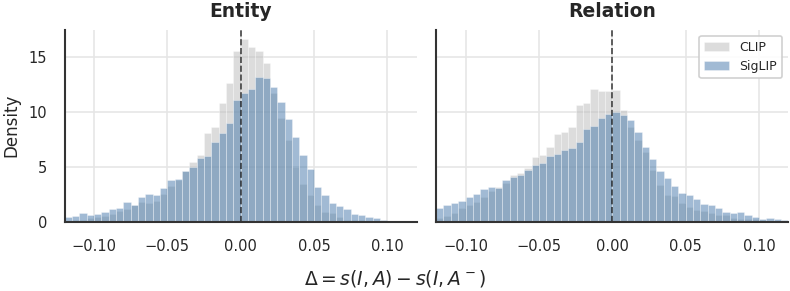

✓ Saved: ../paper_figures/ht_margin_hist_entity_vs_relation.pdf


In [17]:
# =============================================================================
# FIGURE: Margin Distribution Histograms - Entity vs Relation
# =============================================================================
# Side-by-side histograms comparing margin distributions for selected models

apply_tueplots_style(half_width=False)

# Select models to compare
COMPARE_MODELS = ['CLIP', 'SigLIP']
COMPARE_MODELS = [m for m in COMPARE_MODELS if m in all_margins]

if len(COMPARE_MODELS) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.4), sharey=True)
    
    bins = np.linspace(-0.15, 0.15, 61)  # Fine-grained bins
    
    for ax, (category, conditions) in zip(axes, [('Entity', ENTITY_CONDITIONS), 
                                                   ('Relation', RELATION_CONDITIONS)]):
        for model in COMPARE_MODELS:
            df = all_margins[model]
            subset = df[df['condition'].isin(conditions)]
            margins = subset['margin'].values
            
            # Histogram with transparency
            ax.hist(margins, bins=bins, alpha=0.5, label=model, 
                    color=get_model_color(model), edgecolor='white', linewidth=0.3,
                    density=True)
        
        # Reference line at 0
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        
        # Formatting
        ax.set_title(category, fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlim(-0.12, 0.12)
    
    axes[0].set_ylabel('Density', fontsize=8)
    axes[1].legend(loc='upper right', fontsize=6, frameon=True, framealpha=0.9)
    
    # Shared x-label
    fig.supxlabel(r'$\Delta = s(I, A) - s(I, A^-)$', fontsize=9, y=0.15)
    
    sns.despine()
    plt.tight_layout(rect=[0, 0.08, 1, 1])  # Leave space for shared x-label
    plt.savefig('../paper_figures/ht_margin_hist_entity_vs_relation.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"✓ Saved: ../paper_figures/ht_margin_hist_entity_vs_relation.pdf")
else:
    print("⚠ Not enough models to compare")

In [15]:
# =============================================================================
# FIGURE: Cumulative Distribution Function (CDF) of Margins
# =============================================================================
# CDF shows Pr[margin <= x] - clearer view of distribution tails

apply_tueplots_style(half_width=False)

COMPARE_MODELS = ['CLIP', 'NegCLIP', 'CS-CLIP']
COMPARE_MODELS = [m for m in COMPARE_MODELS if m in all_margins]

if len(COMPARE_MODELS) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.2), sharey=True)
    
    for ax, (category, conditions) in zip(axes, [('Entity', ENTITY_CONDITIONS), 
                                                   ('Relation', RELATION_CONDITIONS)]):
        for model in COMPARE_MODELS:
            df = all_margins[model]
            subset = df[df['condition'].isin(conditions)]
            margins = np.sort(subset['margin'].values)
            cdf = np.arange(1, len(margins) + 1) / len(margins)
            
            ax.plot(margins, cdf, label=model, color=get_model_color(model), linewidth=1.5)
        
        # Reference line at 0 (decision boundary)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
        
        # Shade negative margin region (failures)
        ax.axvspan(-0.15, 0, alpha=0.1, color='red')
        
        # Formatting
        ax.set_xlabel('Margin (ST - HT)', fontsize=8)
        ax.set_title(category, fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlim(-0.12, 0.12)
        ax.set_ylim(0, 1)
    
    axes[0].set_ylabel('CDF: Pr[margin ≤ x]', fontsize=8)
    axes[1].legend(loc='lower right', fontsize=6, frameon=True, framealpha=0.9)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/ht_margin_cdf_entity_vs_relation.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"✓ Saved: ../paper_figures/ht_margin_cdf_entity_vs_relation.pdf")
else:
    print("⚠ Not enough models to compare")

⚠ Not enough models to compare


In [16]:
# =============================================================================
# FIGURE: Per-Condition Margin Box Plots
# =============================================================================
# Box plots showing margin distribution for each condition, grouped by Entity/Relation

apply_tueplots_style(half_width=False)

COMPARE_MODELS = ['CLIP', 'NegCLIP', 'CS-CLIP']
COMPARE_MODELS = [m for m in COMPARE_MODELS if m in all_margins]

if len(COMPARE_MODELS) >= 2:
    # Prepare data for box plot
    box_data = []
    for model in COMPARE_MODELS:
        df = all_margins[model]
        for condition, (display_name, category) in CONDITION_MAP.items():
            subset = df[df['condition'] == condition]
            if len(subset) > 0:
                for margin in subset['margin'].values:
                    box_data.append({
                        'model': model,
                        'condition': display_name,
                        'category': category,
                        'margin': margin,
                    })
    
    box_df = pd.DataFrame(box_data)
    
    # Ordered conditions: Entity first, then Relation
    entity_display = [CONDITION_MAP[c][0] for c in ENTITY_CONDITIONS if c in CONDITION_MAP]
    relation_display = [CONDITION_MAP[c][0] for c in RELATION_CONDITIONS if c in CONDITION_MAP]
    condition_order = entity_display + relation_display
    
    fig, ax = plt.subplots(figsize=(6.5, 2.8))
    
    # Use seaborn boxplot with hue
    palette = {m: get_model_color(m) for m in COMPARE_MODELS}
    sns.boxplot(data=box_df, x='condition', y='margin', hue='model', 
                order=condition_order, palette=palette, 
                linewidth=0.6, fliersize=1.5, width=0.7, ax=ax)
    
    # Reference line at 0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    
    # Category separator
    n_entity = len(entity_display)
    ax.axvline(x=n_entity - 0.5, color='black', linewidth=1.5, alpha=0.8)
    
    # Category labels
    ax.text(n_entity / 2 - 0.5, ax.get_ylim()[1] * 0.95, 'Entity', 
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(n_entity + (len(condition_order) - n_entity) / 2 - 0.5, ax.get_ylim()[1] * 0.95, 
            'Relation', ha='center', va='top', fontsize=8, fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Condition', fontsize=8)
    ax.set_ylabel('$\Delta = s(I,A) - s(I,A^-)$', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    ax.legend(loc='lower right', fontsize=6, frameon=True, framealpha=0.9)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/ht_margin_boxplot_per_condition.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"✓ Saved: ../paper_figures/ht_margin_boxplot_per_condition.pdf")
else:
    print("⚠ Not enough models to compare")

⚠ Not enough models to compare


In [27]:
# =============================================================================
# SUMMARY TABLE: Margin Statistics per Model
# =============================================================================
# Print detailed margin statistics for each model

print("="*90)
print("MARGIN STATISTICS SUMMARY")
print("="*90)

# Pivot to show Entity/Relation side by side
pivot_stats = margin_stats_df[margin_stats_df['category'] != 'Overall'].pivot(
    index='model', 
    columns='category', 
    values=['accuracy', 'median', 'iqr', 'hard_fail_rate', 'worst_5pct_mean']
)

# Flatten column names
pivot_stats.columns = [f'{stat}_{cat}' for stat, cat in pivot_stats.columns]

# Sort by overall accuracy
overall_acc = margin_stats_df[margin_stats_df['category'] == 'Overall'].set_index('model')['accuracy']
pivot_stats = pivot_stats.reindex(overall_acc.sort_values(ascending=False).index)

print("\nKey metrics by category:")
print("-" * 90)
display_cols = [
    'accuracy_Entity', 'median_Entity', 'hard_fail_rate_Entity',
    'accuracy_Relation', 'median_Relation', 'hard_fail_rate_Relation',
]
print(pivot_stats[[c for c in display_cols if c in pivot_stats.columns]].round(3).to_string())

print("\n" + "="*90)
print("WORST 5% MEAN MARGIN (Lower = More severe failures)")
print("="*90)
worst5_cols = ['worst_5pct_mean_Entity', 'worst_5pct_mean_Relation']
print(pivot_stats[[c for c in worst5_cols if c in pivot_stats.columns]].round(4).to_string())

MARGIN STATISTICS SUMMARY

Key metrics by category:
------------------------------------------------------------------------------------------
                accuracy_Entity  median_Entity  hard_fail_rate_Entity  accuracy_Relation  median_Relation  hard_fail_rate_Relation
model                                                                                                                             
CS-CLIP                  75.420          0.021                 15.858             65.467            0.014                   25.064
FSC-CLIP-CC3M            77.680          0.027                 16.524             54.067            0.004                   37.029
CON-CLIP                 75.981          0.020                 15.701             48.825           -0.001                   39.970
FSC-CLIP-COCO            74.895          0.023                 18.459             47.919           -0.002                   42.091
ReadCLIP                 69.396          0.015                 22.023  

## Section 10: Modern Comparative Visualizations

Additional figures for comparing methods with modern, publication-ready styles.

In [ ]:
# =============================================================================
# FIGURE: Dumbbell Plot (Entity vs Relation Gap)
# =============================================================================
# Shows Entity and Relation accuracy as connected dots - emphasizes the gap

apply_tueplots_style(half_width=False)

# Sort by overall accuracy, take top N for readability
TOP_N = 12
df_plot = ht_summary_df.head(TOP_N).copy()
models = df_plot.index.tolist()

fig, ax = plt.subplots(figsize=(5.0, 0.32 * len(models)))

y_pos = np.arange(len(models))

# Draw connecting lines first (the "dumbbells")
for i, model in enumerate(models):
    entity_acc = df_plot.loc[model, 'Entity']
    relation_acc = df_plot.loc[model, 'Relation']
    
    # Line color based on gap direction
    line_color = '#999999'
    ax.plot([relation_acc, entity_acc], [i, i], 
            color=line_color, linewidth=1.5, zorder=1)

# Draw dots
entity_vals = df_plot['Entity'].values
relation_vals = df_plot['Relation'].values

ax.scatter(entity_vals, y_pos, s=60, color=COLOR_ENTITY, 
           edgecolor='white', linewidth=0.8, zorder=2, label='Entity')
ax.scatter(relation_vals, y_pos, s=60, color=COLOR_RELATION, 
           edgecolor='white', linewidth=0.8, zorder=2, label='Relation')

# Highlight key models
for i, model in enumerate(models):
    if model == 'CS-CLIP':
        ax.scatter([df_plot.loc[model, 'Entity']], [i], s=90, 
                   color=COLOR_ENTITY, edgecolor='black', linewidth=1.5, zorder=3)
        ax.scatter([df_plot.loc[model, 'Relation']], [i], s=90, 
                   color=COLOR_RELATION, edgecolor='black', linewidth=1.5, zorder=3)
    elif model == 'CLIP':
        ax.scatter([df_plot.loc[model, 'Entity']], [i], s=60, 
                   color=COLOR_ENTITY, edgecolor='gray', linewidth=1.2, zorder=3, marker='s')
        ax.scatter([df_plot.loc[model, 'Relation']], [i], s=60, 
                   color=COLOR_RELATION, edgecolor='gray', linewidth=1.2, zorder=3, marker='s')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(models, fontsize=7)
ax.set_xlabel('HT-Accuracy (%)', fontsize=8)
ax.set_xlim(20, 100)
ax.tick_params(axis='x', labelsize=7)

# Legend
ax.legend(loc='lower right', fontsize=7, frameon=True, framealpha=0.9)

# Grid on x-axis only
ax.xaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.4)
ax.set_axisbelow(True)

sns.despine(left=True)
plt.tight_layout()
plt.savefig('../paper_figures/ht_dumbbell_entity_relation.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_dumbbell_entity_relation.pdf")

In [ ]:
# =============================================================================
# FIGURE: Lollipop Chart (Improvement over CLIP Baseline)
# =============================================================================
# Clean visualization showing delta improvement of each method over CLIP

apply_tueplots_style(half_width=False)

# Get CLIP baseline
clip_overall = ht_summary_df.loc['CLIP', 'Overall']
clip_entity = ht_summary_df.loc['CLIP', 'Entity']
clip_relation = ht_summary_df.loc['CLIP', 'Relation']

# Compute deltas
df_delta = ht_summary_df.copy()
df_delta['Delta_Overall'] = df_delta['Overall'] - clip_overall
df_delta['Delta_Entity'] = df_delta['Entity'] - clip_entity
df_delta['Delta_Relation'] = df_delta['Relation'] - clip_relation

# Remove CLIP itself, sort by delta
df_delta = df_delta.drop('CLIP').sort_values('Delta_Overall', ascending=True)
models = df_delta.index.tolist()

fig, ax = plt.subplots(figsize=(4.5, 0.28 * len(models)))

y_pos = np.arange(len(models))
deltas = df_delta['Delta_Overall'].values

# Colors: green for positive, red for negative
colors = [COLOR_OURS if d > 0 else COLORBLIND_PALETTE[1] for d in deltas]

# Draw stems
for i, (delta, model) in enumerate(zip(deltas, models)):
    color = COLOR_OURS if delta > 0 else COLORBLIND_PALETTE[1]
    ax.hlines(y=i, xmin=0, xmax=delta, color=color, linewidth=1.5, alpha=0.7)

# Draw dots
ax.scatter(deltas, y_pos, s=50, c=colors, edgecolor='white', linewidth=0.6, zorder=3)

# Highlight CS-CLIP
if 'CS-CLIP' in models:
    idx = models.index('CS-CLIP')
    ax.scatter([deltas[idx]], [idx], s=80, c=COLOR_OURS, 
               edgecolor='black', linewidth=1.5, zorder=4)
    ax.annotate(f'+{deltas[idx]:.1f}', xy=(deltas[idx], idx), 
                xytext=(5, 0), textcoords='offset points',
                fontsize=7, fontweight='bold', va='center')

# Reference line at 0 (CLIP baseline)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)
ax.text(0.5, len(models) - 0.5, 'CLIP baseline', fontsize=6, va='bottom', ha='left', alpha=0.7)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(models, fontsize=7)
ax.set_xlabel('$\Delta$ HT-Accuracy vs CLIP (pp)', fontsize=8)
ax.tick_params(axis='x', labelsize=7)

# Grid
ax.xaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.4)
ax.set_axisbelow(True)

sns.despine(left=True)
plt.tight_layout()
plt.savefig('../paper_figures/ht_lollipop_delta_clip.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_lollipop_delta_clip.pdf")

In [ ]:
# =============================================================================
# FIGURE: Slope Chart (Entity → Relation Performance Change)
# =============================================================================
# Shows how each model's accuracy changes from Entity to Relation

apply_tueplots_style(half_width=True)

# Select key models for clarity
KEY_MODELS = ['CLIP', 'NegCLIP', 'SigLIP', 'SigLIP2', 'TSVLC', 'CS-CLIP']
KEY_MODELS = [m for m in KEY_MODELS if m in ht_summary_df.index]

fig, ax = plt.subplots(figsize=(2.8, 3.2))

x_positions = [0, 1]  # Entity at 0, Relation at 1

for model in KEY_MODELS:
    entity_acc = ht_summary_df.loc[model, 'Entity']
    relation_acc = ht_summary_df.loc[model, 'Relation']
    
    # Style based on model
    if model == 'CS-CLIP':
        color = COLOR_OURS
        linewidth = 2.2
        alpha = 1.0
        marker = 'o'
        markersize = 8
        zorder = 10
    elif model == 'CLIP':
        color = COLOR_BASELINE
        linewidth = 2.0
        alpha = 0.9
        marker = 's'
        markersize = 7
        zorder = 9
    else:
        color = get_model_color(model)
        linewidth = 1.2
        alpha = 0.6
        marker = 'o'
        markersize = 5
        zorder = 5
    
    # Draw line
    ax.plot(x_positions, [entity_acc, relation_acc], 
            color=color, linewidth=linewidth, alpha=alpha, zorder=zorder,
            marker=marker, markersize=markersize, markeredgecolor='white', markeredgewidth=0.5)
    
    # Label at right side
    ax.text(1.08, relation_acc, model, fontsize=6, va='center', ha='left',
            color=color, fontweight='bold' if model in ['CS-CLIP', 'CLIP'] else 'normal')

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(['Entity', 'Relation'], fontsize=9, fontweight='bold')
ax.set_ylabel('HT-Accuracy (%)', fontsize=8)
ax.set_xlim(-0.15, 1.5)
ax.set_ylim(20, 100)
ax.tick_params(axis='y', labelsize=7)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.4)
ax.set_axisbelow(True)

sns.despine(bottom=True)
plt.tight_layout()
plt.savefig('../paper_figures/ht_slope_chart.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_slope_chart.pdf")

In [ ]:
# =============================================================================
# FIGURE: Violin Plot with Strip (Margin Distribution)
# =============================================================================
# More informative than histograms - shows full distribution shape

apply_tueplots_style(half_width=False)

COMPARE_MODELS = ['CLIP', 'NegCLIP', 'CS-CLIP']
COMPARE_MODELS = [m for m in COMPARE_MODELS if m in all_margins]

if len(COMPARE_MODELS) >= 2:
    # Prepare data
    violin_data = []
    for model in COMPARE_MODELS:
        df = all_margins[model]
        for _, row in df.iterrows():
            category = 'Entity' if row['condition'] in ENTITY_CONDITIONS else 'Relation'
            violin_data.append({
                'Model': model,
                'Category': category,
                'Margin': row['margin']
            })
    
    violin_df = pd.DataFrame(violin_data)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.6), sharey=True)
    
    palette = {m: get_model_color(m) for m in COMPARE_MODELS}
    
    for ax, category in zip(axes, ['Entity', 'Relation']):
        subset = violin_df[violin_df['Category'] == category]
        
        # Violin plot
        parts = ax.violinplot([subset[subset['Model'] == m]['Margin'].values for m in COMPARE_MODELS],
                              positions=range(len(COMPARE_MODELS)), widths=0.7,
                              showmeans=False, showmedians=True, showextrema=False)
        
        # Color the violins
        for i, (pc, model) in enumerate(zip(parts['bodies'], COMPARE_MODELS)):
            pc.set_facecolor(palette[model])
            pc.set_edgecolor('white')
            pc.set_alpha(0.7)
        
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.5)
        
        # Add strip plot (jittered points) - subsample for clarity
        for i, model in enumerate(COMPARE_MODELS):
            model_margins = subset[subset['Model'] == model]['Margin'].values
            # Subsample if too many points
            if len(model_margins) > 200:
                idx = np.random.choice(len(model_margins), 200, replace=False)
                model_margins = model_margins[idx]
            jitter = np.random.uniform(-0.15, 0.15, len(model_margins))
            ax.scatter(i + jitter, model_margins, s=3, alpha=0.3, 
                       color=palette[model], edgecolor='none')
        
        # Reference line at 0
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        
        # Formatting
        ax.set_xticks(range(len(COMPARE_MODELS)))
        ax.set_xticklabels(COMPARE_MODELS, fontsize=7)
        ax.set_title(category, fontsize=9, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylim(-0.15, 0.15)
    
    axes[0].set_ylabel(r'$\delta = s(I, A) - s(I, A^-)$', fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/ht_violin_margin.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"✓ Saved: ../paper_figures/ht_violin_margin.pdf")
else:
    print("⚠ Not enough models")

In [ ]:
# =============================================================================
# FIGURE: Bump Chart (Ranking Changes Entity → Relation)
# =============================================================================
# Shows how model rankings shift between Entity and Relation

apply_tueplots_style(half_width=True)

# Get rankings
entity_rank = ht_summary_df['Entity'].rank(ascending=False).astype(int)
relation_rank = ht_summary_df['Relation'].rank(ascending=False).astype(int)

# Select models to show (top performers + key baselines)
TOP_N = 10
top_models = ht_summary_df.head(TOP_N).index.tolist()

fig, ax = plt.subplots(figsize=(2.5, 3.5))

x_positions = [0, 1]

for model in top_models:
    ent_r = entity_rank[model]
    rel_r = relation_rank[model]
    
    # Style
    if model == 'CS-CLIP':
        color = COLOR_OURS
        linewidth = 2.5
        alpha = 1.0
        fontweight = 'bold'
    elif model == 'CLIP':
        color = COLOR_BASELINE
        linewidth = 2.0
        alpha = 0.85
        fontweight = 'bold'
    else:
        color = '#888888'
        linewidth = 1.0
        alpha = 0.5
        fontweight = 'normal'
    
    # Draw line (inverted y-axis: rank 1 at top)
    ax.plot(x_positions, [ent_r, rel_r], 
            color=color, linewidth=linewidth, alpha=alpha,
            marker='o', markersize=6, markeredgecolor='white', markeredgewidth=0.5)
    
    # Labels
    ax.text(-0.12, ent_r, model, fontsize=5.5, va='center', ha='right',
            color=color, fontweight=fontweight, alpha=max(alpha, 0.7))
    ax.text(1.12, rel_r, model, fontsize=5.5, va='center', ha='left',
            color=color, fontweight=fontweight, alpha=max(alpha, 0.7))

# Formatting (inverted y-axis for rankings)
ax.set_xticks(x_positions)
ax.set_xticklabels(['Entity', 'Relation'], fontsize=9, fontweight='bold')
ax.set_ylabel('Rank', fontsize=8)
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(TOP_N + 0.5, 0.5)  # Inverted: rank 1 at top
ax.set_yticks(range(1, TOP_N + 1))
ax.tick_params(axis='y', labelsize=6)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.4)
ax.set_axisbelow(True)

sns.despine(bottom=True)
plt.tight_layout()
plt.savefig('../paper_figures/ht_bump_chart_ranking.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_bump_chart_ranking.pdf")

In [ ]:
# =============================================================================
# FIGURE: Scatter Plot HT-Acc vs FT-Acc with Quadrants
# =============================================================================
# Shows correlation between metrics with meaningful quadrants

apply_tueplots_style(half_width=True)

fig, ax = plt.subplots(figsize=(3.5, 3.2))

# Get data
ht_acc = ht_summary_df['Overall'].values
ft_acc = ft_summary_df.reindex(ht_summary_df.index)['Overall'].values
models = ht_summary_df.index.tolist()

# Draw points
for i, model in enumerate(models):
    if model == 'CS-CLIP':
        color = COLOR_OURS
        size = 100
        edgecolor = 'black'
        linewidth = 1.5
        zorder = 10
        marker = 'o'
    elif model == 'CLIP':
        color = COLOR_BASELINE
        size = 80
        edgecolor = 'gray'
        linewidth = 1.2
        zorder = 9
        marker = 's'
    else:
        color = COLORBLIND_PALETTE[0]
        size = 40
        edgecolor = 'white'
        linewidth = 0.5
        zorder = 5
        marker = 'o'
    
    ax.scatter(ht_acc[i], ft_acc[i], s=size, c=color, marker=marker,
               edgecolor=edgecolor, linewidth=linewidth, zorder=zorder, alpha=0.85)

# Label key models
key_labels = ['CS-CLIP', 'CLIP', 'NegCLIP', 'SigLIP']
for i, model in enumerate(models):
    if model in key_labels:
        offset = (5, 5) if model != 'CLIP' else (-5, -10)
        ax.annotate(model, (ht_acc[i], ft_acc[i]), xytext=offset,
                    textcoords='offset points', fontsize=6, 
                    fontweight='bold' if model in ['CS-CLIP', 'CLIP'] else 'normal')

# Diagonal line (perfect correlation)
lims = [min(min(ht_acc), min(ft_acc)) - 2, max(max(ht_acc), max(ft_acc)) + 2]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=0.8, label='y=x')

# Quadrant lines at medians
median_ht = np.median(ht_acc)
median_ft = np.median(ft_acc)
ax.axvline(x=median_ht, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)
ax.axhline(y=median_ft, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)

# Formatting
ax.set_xlabel('HT-Accuracy (%)', fontsize=8)
ax.set_ylabel('FT-Accuracy (%)', fontsize=8)
ax.tick_params(axis='both', labelsize=7)
ax.set_xlim(lims)
ax.set_ylim(lims)

# Equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Correlation
corr = np.corrcoef(ht_acc, ft_acc)[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
        fontsize=7, va='top', ha='left')

sns.despine()
plt.tight_layout()
plt.savefig('../paper_figures/ht_vs_ft_scatter_quadrant.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: ../paper_figures/ht_vs_ft_scatter_quadrant.pdf")